In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('../')

import random
import pandas  as pd
import numpy   as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from optbinning import OptimalBinning

from sklearn.pipeline      import Pipeline
from sklearn.compose       import ColumnTransformer
from sklearn.preprocessing import scale, robust_scale, power_transform

from src import *

set_seeds()
pd.set_option('display.max_columns', None)
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
train_raw = pd.read_csv('../data/raw/cs-training.csv').drop(columns=['Unnamed: 0'])
print(f"Data shape: {train_raw.shape}")

X_train = train_raw.drop(columns=['SeriousDlqin2yrs']).copy()
y_train = train_raw['SeriousDlqin2yrs'].copy()

Data shape: (150000, 11)


In [3]:
config = Config()

pipeline = create_preprocessing_pipeline(config)

pipeline.fit(X_train, y_train)
X_train_processed = pd.DataFrame(pipeline.transform(X_train), columns=pipeline.get_feature_names_out())

In [4]:
X_train_processed.describe()

,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,MonthlyIncome_missing,NumberOfDependents_missing,is_young,is_senior,MonthlyIncome_clipped,MonthlyIncome_zero,LowIncome,utilization_clipped,utilization_99999990,DebtRatio_low,DebtRatio_clipped,DebtRatio_zero,DebtRatio_whole,age^2,age^3,DebtRatio^2,DebtRatio^3,NumberOfOpenCreditLinesAndLoans^2,NumberOfOpenCreditLinesAndLoans^3,NumberRealEstateLoansOrLines^2,NumberRealEstateLoansOrLines^3,total_delinquencies,has_delinquency,weighted_delinquencies
count,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05
mean,8.981260e-17,-1.466560e-16,-1.061077e-17,-2.681115e-17,1.234450e-16,-1.811410e-16,2.311632e-17,-4.357995e-17,-1.042129e-18,1.515825e-17,4.054831e-17,-1.117921e-17,-3.789561e-18,-5.153803e-17,4.736952e-19,2.766380e-17,-3.221127e-18,-1.231607e-17,1.477929e-17,7.863340e-17,5.456968e-17,1.946887e-17,-6.044350e-17,-8.337035e-17,-7.958079e-18,-2.666904e-17,1.397401e-17,-2.925541e-16,4.467893e-16,8.905469e-18,4.320100e-17,-5.153803e-17,2.842171e-18,-5.684342e-19
std,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00
min,-9.133445e-01,-2.127567e+00,-3.687091e-01,-1.896224e+00,-1.270292e+00,-3.507531e+00,-2.310440e-01,-1.006900e+00,-2.177823e-01,-6.802357e-01,-4.971963e-01,-1.638985e-01,-2.499619e-01,-6.893383e-01,-2.936803e-01,-1.049443e-01,-2.077474e-01,-1.504702e-01,-2.709084e-01,-8.105785e-01,-5.108630e-01,-1.679079e-01,-4.992290e-01,-1.575598e+00,-1.200172e+00,-1.353925e+00,-9.466674e-01,-2.988412e+00,-2.881055e+00,-6.344194e-01,-4.278152e-01,-3.806136e-01,-5.037784e-01,-3.363348e-01
25%,-8.278820e-01,-7.666002e-01,-3.687091e-01,-5.528119e-01,-8.547205e-01,-4.959729e-01,-2.310440e-01,-1.006900e+00,-2.177823e-01,-6.802357e-01,-4.971963e-01,-1.638985e-01,-2.499619e-01,-6.893383e-01,-2.936803e-01,-1.049443e-01,-2.077474e-01,-1.504702e-01,-2.709084e-01,-8.105785e-01,-5.108630e-01,-1.679079e-01,-4.992290e-01,-7.961715e-01,-7.736520e-01,-8.133139e-01,-7.971407e-01,-4.984560e-01,-4.853795e-01,-6.344194e-01,-4.278152e-01,-3.806136e-01,-5.037784e-01,-3.363348e-01
50%,-4.721729e-01,-1.806820e-02,-3.687091e-01,4.880112e-02,-1.019999e-01,1.855259e-01,-2.310440e-01,7.506605e-03,-2.177823e-01,-6.802357e-01,-4.971963e-01,-1.638985e-01,-2.499619e-01,-6.893383e-01,-2.936803e-01,-1.049443e-01,-2.077474e-01,-1.504702e-01,-2.709084e-01,-8.105785e-01,-5.108630e-01,-1.679079e-01,-4.992290e-01,-1.531448e-01,-2.611490e-01,-1.230185e-01,-3.550026e-01,2.018068e-01,2.100955e-01,-3.102487e-01,-3.372201e-01,-3.806136e-01,-5.037784e-01,-3.363348e-01
75%,6.863061e-01,7.304638e-01,-3.687091e-01,5.716748e-01,7.137267e-01,6.690570e-01,-2.310440e-01,1.021913e+00,-2.177823e-01,2.539744e-01,-4.971963e-01,-1.638985e-01,-2.499619e-01,1.450666e+00,-2.936803e-01,-1.049443e-01,-2.077474e-01,-1.504702e-01,-2.709084e-01,1.233687e+00,-5.108630e-01,-1.679079e-01,-4.992290e-01,6.419956e-01,5.212497e-01,6.473674e-01,4.665001e-01,6.829960e-01,6.827437e-01,6.622635e-01,2.969452e-01,-3.806136e-01,-5.037784e-01,-3.363348e-01
max,1.948048e+00,2.363624e+00,5.629975e+00,2.889488

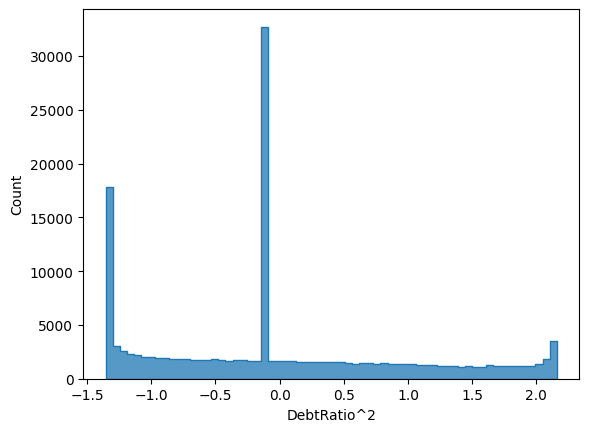

In [5]:
sns.histplot(data=X_train_processed, x='DebtRatio^2', element='step');